# 01 — Khám phá dữ liệu và kiểm định quần thể

**Quyết định kinh doanh.** Clustomer phân khúc các khách hàng đã định danh tại Vương quốc Anh dựa trên giao dịch mua hàng hoàn tất, giúp đội ngũ CRM ưu tiên các thử nghiệm giữ chân, tái kích hoạt và phát triển giá trị khách hàng. Phân khúc chỉ hỗ trợ ra quyết định, không tự động lựa chọn ưu đãi hay xác định khách hàng đủ điều kiện.

**Đơn vị dự đoán.** Một `Customer ID` đã xác định, được chấm điểm tại một mốc thời gian khai báo trước và chỉ sử dụng các giao dịch có sẵn đến thời điểm đó.

**Phạm vi được duyệt.** Tệp dữ liệu một năm đã lưu trong kho mã nguồn; Vương quốc Anh là quần thể triển khai. Các dòng ngoài Vương quốc Anh, thiếu mã khách hàng, giao dịch hủy và hoàn trả vẫn xuất hiện trong kết quả kiểm định nhưng không bị âm thầm trộn vào RFM của giao dịch mua gộp.


In [1]:
from pathlib import Path
import json, os, warnings
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "online_retail_II.csv"
OUT = ROOT / "outputs"
INTERMEDIATE = OUT / "intermediate"
REPORTS = OUT / "reports"
FIGURES = OUT / "figures"
MODELS = OUT / "models"
for directory in (INTERMEDIATE, REPORTS, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)
(ROOT / "experiments").mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEV_CUTOFF = pd.Timestamp("2010-08-31 23:59:59")
VALIDATION_END = pd.Timestamp("2010-10-31 23:59:59")
HOLDOUT_END = pd.Timestamp("2010-12-09 23:59:59")
print(f"Thư mục gốc dự án: {ROOT}")

Thư mục gốc dự án: C:\Users\lqb46\Documents\Projects\Clustomer


## 1. Nguồn gốc, lược đồ và độ bao phủ dữ liệu

In [2]:
raw = pd.read_csv(DATA_PATH)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
print(f"Số dòng × số cột: {raw.shape[0]:,} × {raw.shape[1]}")
print(f"Giai đoạn dữ liệu: {raw['InvoiceDate'].min()} → {raw['InvoiceDate'].max()}")
display(raw.head(), raw.dtypes.rename("dtype").to_frame())

Số dòng × số cột: 525,461 × 8
Giai đoạn dữ liệu: 2009-12-01 07:45:00 → 2010-12-09 20:01:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [3]:
quality = pd.DataFrame({
    "missing_n": raw.isna().sum(),
    "missing_pct": raw.isna().mean().mul(100),
    "unique_n": raw.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)
display(quality)
print(f"Số dòng trùng hoàn toàn: {raw.duplicated().sum():,} ({raw.duplicated().mean():.2%})")
print(f"Số ngày không thể chuyển đổi: {raw['InvoiceDate'].isna().sum():,}")

,missing_n,missing_pct,unique_n
Customer ID,107927,20.539,4383
Description,2928,0.557,4681
StockCode,0,0.000,4632
Invoice,0,0.000,28816
Quantity,0,0.000,825
InvoiceDate,0,0.000,25296
Price,0,0.000,1606
Country,0,0.000,40


Số dòng trùng hoàn toàn: 6,865 (1.31%)
Số ngày không thể chuyển đổi: 0


Tệp dữ liệu chứa từng dòng hàng hóa trên hóa đơn, không phải từng khách hàng hay đơn hàng. Vì vậy, `Customer ID` là khóa định danh thực thể và trường phục vụ kiểm định, không bao giờ là đặc trưng phân cụm. Không thể gán phân khúc đáng tin cậy cho các dòng thiếu mã khách hàng; các dòng này phải được loại khỏi mô hình cấp khách hàng, đồng thời vẫn báo cáo khối lượng và doanh thu để thể hiện sai lệch chọn mẫu.


## 2. Kiểm định quần thể và trạng thái giao dịch

In [4]:
audit = raw.copy()
audit["IsCancellationInvoice"] = audit["Invoice"].astype(str).str.startswith("C")
audit["IsNegativeQuantity"] = audit["Quantity"] < 0
audit["PositiveRevenueProxy"] = audit["Quantity"].clip(lower=0) * audit["Price"].clip(lower=0)
display(pd.crosstab(audit["IsCancellationInvoice"], audit["IsNegativeQuantity"], margins=True))
print(f"Số dòng thiếu mã khách hàng: {audit['Customer ID'].isna().sum():,} ({audit['Customer ID'].isna().mean():.2%})")
missing_share = audit.loc[audit['Customer ID'].isna(), 'PositiveRevenueProxy'].sum() / audit['PositiveRevenueProxy'].sum()
print(f"Tỷ trọng doanh thu dương đại diện thuộc các dòng thiếu mã khách hàng: {missing_share:.2%}")
print(f"Số dòng đơn giá bằng 0: {(audit['Price'] == 0).sum():,}; đơn giá âm: {(audit['Price'] < 0).sum():,}")

IsNegativeQuantity,False,True,All
IsCancellationInvoice,,,
False,513134,2121,515255
True,1,10205,10206
All,513135,12326,525461


Số dòng thiếu mã khách hàng: 107,927 (20.54%)
Tỷ trọng doanh thu dương đại diện thuộc các dòng thiếu mã khách hàng: 14.30%
Số dòng đơn giá bằng 0: 3,687; đơn giá âm: 3


In [5]:
country = raw.groupby("Country", dropna=False).agg(
    rows=("Invoice", "size"), customers=("Customer ID", "nunique"), invoices=("Invoice", "nunique")
).sort_values("rows", ascending=False)
country["row_share"] = country["rows"] / len(raw)
display(country.head(12))
print(f"Tỷ trọng dòng thuộc Vương quốc Anh: {raw['Country'].eq('United Kingdom').mean():.2%}")

,rows,customers,invoices,row_share
Country,,,,
United Kingdom,485852,4035,26633,0.925
EIRE,9670,5,457,0.018
Germany,8129,68,513,0.015
France,5772,47,297,0.011
Netherlands,2769,23,150,0.005
Spain,1278,25,85,0.002
Switzerland,1187,14,50,0.002
Portugal,1101,18,57,0.002
Belgium,1054,17,65,0.002


Tỷ trọng dòng thuộc Vương quốc Anh: 92.46%


Quốc gia là quy tắc xác định quần thể đã được duyệt, không phải đặc trưng mô hình. Giữ mô hình chính chỉ cho Vương quốc Anh giúp tránh tạo ra các phân khúc chủ yếu khác nhau về địa lý, trong khi hành động tiếp thị cho các thị trường đó còn phụ thuộc vào logistics, tiền tệ và quy định riêng.


## 3. Dòng trùng lặp, mã hàng đặc biệt và ngoại lệ

In [6]:
duplicate_groups = raw.loc[raw.duplicated(keep=False)].value_counts().value_counts().sort_index()
display(duplicate_groups.rename("groups_with_multiplicity").to_frame())
special = raw.loc[~raw["StockCode"].astype(str).str.fullmatch(r"\d{5}[A-Z]?"), "StockCode"].value_counts().head(25)
display(special.rename("rows").to_frame())

,groups_with_multiplicity
count,
2,5956
3,325
4,39
5,7
6,4


,rows
StockCode,
POST,865
M,850
DOT,736
15056BL,597
79323LP,231
C2,138
18098c,130
79323GR,122
D,100


In [7]:
candidate = raw.loc[raw["Country"].eq("United Kingdom")].drop_duplicates().copy()
flow = []
def record(stage, frame):
    flow.append({"stage": stage, "rows": len(frame), "customers": frame["Customer ID"].nunique(),
                 "revenue_proxy": (frame["Quantity"].clip(lower=0) * frame["Price"].clip(lower=0)).sum()})
record("Dòng thuộc Vương quốc Anh", candidate)
candidate = candidate.loc[candidate["Customer ID"].notna()].copy(); record("Đã xác định khách hàng", candidate)
candidate = candidate.loc[~candidate["Invoice"].astype(str).str.startswith("C")].copy(); record("Không phải hóa đơn hủy", candidate)
candidate = candidate.loc[candidate["Quantity"] > 0].copy(); record("Số lượng dương", candidate)
candidate = candidate.loc[candidate["Price"] > 0].copy(); record("Đơn giá dương", candidate)
candidate["Customer ID"] = candidate["Customer ID"].astype(int)
candidate["LineRevenue"] = candidate["Quantity"] * candidate["Price"]
flow = pd.DataFrame(flow)
flow["rows_removed_from_previous"] = -flow["rows"].diff().fillna(0)
display(flow)

,stage,rows,customers,revenue_proxy,rows_removed_from_previous
0,Dòng thuộc Vương quốc Anh,479047,4035,"8,812,685.403",-0.000
1,Đã xác định khách hàng,372705,4035,"7,381,644.433","106,342.000"
2,Không phải hóa đơn hủy,364255,3971,"7,381,644.433","8,450.000"
3,Số lượng dương,364255,3971,"7,381,644.433",-0.000
4,Đơn giá dương,364233,3969,"7,381,644.433",22.000


,count,mean,min,50%,90%,95%,99%,max,std
Orders,"3,969.000",4.437,1.000,2.000,9.000,13.000,31.000,155.000,7.532
Revenue,"3,969.000","1,859.825",2.950,663.310,"3,546.044","5,848.688","19,349.121","349,164.350","7,377.489"
LastPurchase,3969,2010-09-10 11:01:14.618291968,2009-12-01 10:49:00,2010-10-19 09:07:00,2010-12-02 18:09:24,2010-12-07 12:46:36,2010-12-09 13:44:57.600000,2010-12-09 20:01:00,NaN
Products,"3,969.000",63.198,1.000,38.000,149.200,204.000,389.000,"1,509.000",81.611


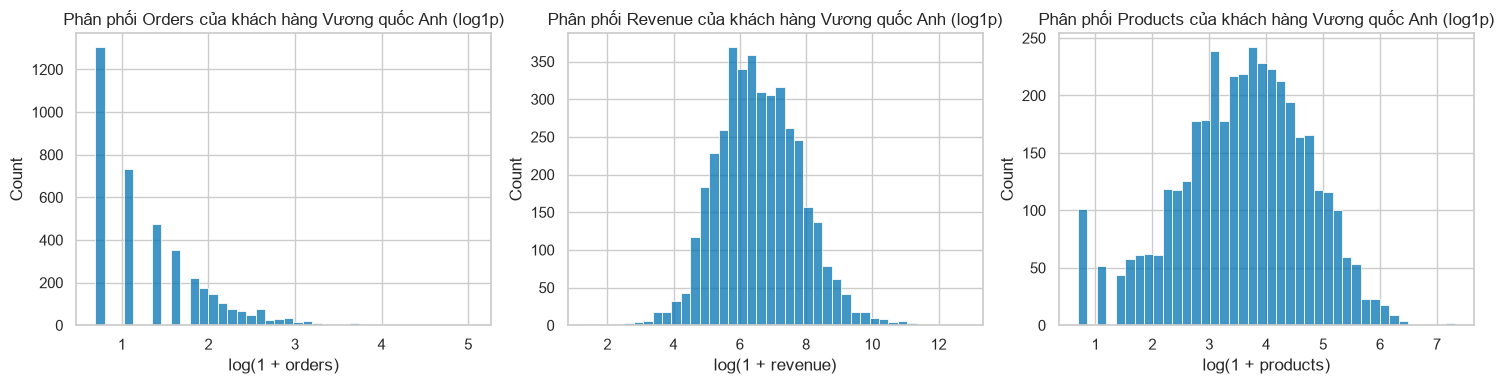

In [8]:
customer_check = candidate.groupby("Customer ID").agg(
    Orders=("Invoice", "nunique"), Revenue=("LineRevenue", "sum"),
    LastPurchase=("InvoiceDate", "max"), Products=("StockCode", "nunique")
)
display(customer_check.describe(percentiles=[.5,.9,.95,.99]).T)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Orders", "Revenue", "Products"]):
    sns.histplot(np.log1p(customer_check[col]), bins=40, ax=ax)
    ax.set_title(f"Phân phối {col} của khách hàng Vương quốc Anh (log1p)")
    ax.set_xlabel(f"log(1 + {col.lower()})")
plt.tight_layout(); plt.show()

Các giá trị ngoại lệ được xem là hành vi khách hàng thực tế trừ khi nguồn gốc dữ liệu chứng minh đó là lỗi. Chúng được giữ trong hồ sơ kinh doanh gốc; các phép biến đổi bền vững và `log1p` được đánh giá khi phân cụm. Cách làm này tránh âm thầm loại bỏ khách hàng giá trị cao, vốn là nhóm mà phân khúc CRM cần mô tả rõ nhất.


## 4. Phạm vi thời gian và các cửa sổ mô hình đã duyệt

,Orders,Revenue,Customers
InvoiceDate,,,
2009-12-31,1429,"610,346.630",904
2010-01-31,906,"415,120.502",663
2010-02-28,1001,"409,265.826",713
2010-03-31,1396,"587,165.941",984
2010-04-30,1222,"500,798.551",876
2010-05-31,1270,"501,394.560",901
2010-06-30,1377,"538,672.610",968
2010-07-31,1272,"502,350.000",856
2010-08-31,1193,"506,470.040",849


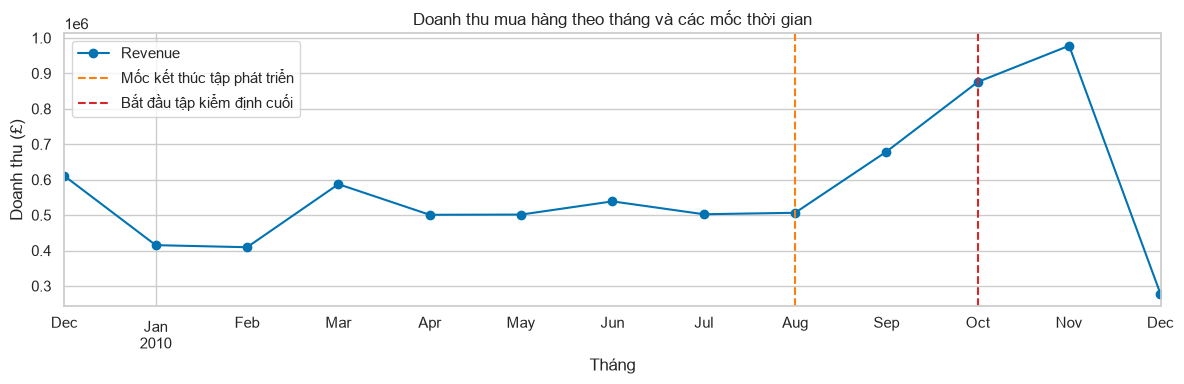

In [9]:
monthly = candidate.set_index("InvoiceDate").resample("ME").agg(
    Orders=("Invoice", "nunique"), Revenue=("LineRevenue", "sum"), Customers=("Customer ID", "nunique")
)
display(monthly)
ax = monthly[["Revenue"]].plot(figsize=(12,4), marker="o", legend=False)
ax.axvline(DEV_CUTOFF, color="tab:orange", ls="--", label="Mốc kết thúc tập phát triển")
ax.axvline(VALIDATION_END, color="tab:red", ls="--", label="Bắt đầu tập kiểm định cuối")
ax.set(title="Doanh thu mua hàng theo tháng và các mốc thời gian", ylabel="Doanh thu (£)", xlabel="Tháng")
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
returns_audit = raw.loc[
    raw["Country"].eq("United Kingdom") & raw["Customer ID"].notna() &
    (raw["Invoice"].astype(str).str.startswith("C") | (raw["Quantity"] < 0))
].copy()
audit_summary = {
    "raw_rows": int(len(raw)), "raw_customers": int(raw["Customer ID"].nunique()),
    "uk_clean_purchase_rows": int(len(candidate)), "uk_clean_customers": int(candidate["Customer ID"].nunique()),
    "exact_duplicates_removed": int(raw.loc[raw["Country"].eq("United Kingdom")].duplicated().sum()),
    "return_or_cancel_rows_audit": int(len(returns_audit)),
    "data_start": str(candidate["InvoiceDate"].min()), "data_end": str(candidate["InvoiceDate"].max()),
}
candidate.to_csv(INTERMEDIATE / "uk_completed_purchases.csv", index=False)
returns_audit.to_csv(INTERMEDIATE / "uk_returns_audit.csv", index=False)
(REPORTS / "eda_summary.json").write_text(json.dumps(audit_summary, indent=2), encoding="utf-8")
print(json.dumps(audit_summary, indent=2))

{
  "raw_rows": 525461,
  "raw_customers": 4383,
  "uk_clean_purchase_rows": 364233,
  "uk_clean_customers": 3969,
  "exact_duplicates_removed": 6805,
  "return_or_cancel_rows_audit": 8472,
  "data_start": "2009-12-01 07:45:00",
  "data_end": "2010-12-09 20:01:00"
}


## Quyết định sau EDA

Quần thể mô hình triển khai gồm các khách hàng đã định danh tại Vương quốc Anh, với giao dịch mua hoàn tất, đã loại dòng trùng chính xác, có số lượng và đơn giá dương. Giao dịch hoàn trả và hủy được lưu riêng để quản trị; lược đồ hiện có không bảo đảm ghép chúng đáng tin cậy với giao dịch bán ban đầu. Dữ liệu kết thúc ngày 9 tháng 12 năm 2010 nên không thể đưa ra kết luận nào về năm 2011.

**Điều kiện qua cổng kiểm định:** quần thể đã lưu không còn dòng trùng, thiếu mã khách hàng, giao dịch hủy, số lượng hoặc đơn giá không dương hay dòng ngoài Vương quốc Anh; các số đếm hiển thị phải khớp với tệp JSON đã lưu.
